# Covariance tutorial

This notebook reads precomputed NJOY/ERRORR covariance files from the
JEFF-3.3 ECCO-33 database. It demonstrates the most common `Covariance`
operations: loading a nuclide, inspecting MF/MT availability, extracting
diagonal and off-diagonal blocks, and plotting a block.

The `sandy` package is required by `Covariance`. If it is not installed, the
notebook still checks that the tutorial data are present and skips the
covariance-specific cells.

In [6]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))

def find_project_root(start: Path | None = None) -> Path:
    """Find the pyNDUS repository root."""
    start = (start or Path.cwd()).resolve()

    for directory in (start, *start.parents):
        if (
            (directory / "setup.py").is_file()
            and (directory / "src" / "pyNDUS").is_dir()
            and (directory / "docs" / "tutorials").is_dir()
        ):
            return directory

    raise FileNotFoundError(
        f"Could not find the pyNDUS repository root starting from {start}"
    )


PROJECT_ROOT = find_project_root()

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

DATA_ROOT = PROJECT_ROOT / "docs" / "tutorials"
SENS_ROOT = DATA_ROOT / "MG_sensitivities"
COV_ROOT = DATA_ROOT / "MG_covariances"

assert SENS_ROOT.exists(), SENS_ROOT
assert COV_ROOT.exists(), COV_ROOT

In [7]:
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyNDUS import Sensitivity

HAS_SANDY = importlib.util.find_spec("sandy") is not None
if HAS_SANDY:
    from pyNDUS import Covariance
else:
    Covariance = None
    print("sandy is not installed; covariance examples are skipped in this environment.")

## Locate the ERRORR database

In [8]:
LIB = "endfb_80"
EGRID = "ECCO-33"
TEMPERATURE = 300

errorr_dir = COV_ROOT / LIB / EGRID / "errorr"
assert errorr_dir.exists(), errorr_dir

files = sorted(p.name for p in errorr_dir.glob("U-235_300K.errorr*"))
assert files, "No U-235 ERRORR files found"
files[:8]

['U-235_300K.errorr31',
 'U-235_300K.errorr33',
 'U-235_300K.errorr34',
 'U-235_300K.errorr35']

## Build a covariance object

A Serpent sensitivity file is used only to provide the same ECCO-33 grid in
eV. The covariance reader itself uses the precomputed ERRORR files.

In [9]:
grid_source = Sensitivity(SENS_ROOT / "serpent" / "godiva_sens0.m")
group_structure_ev = grid_source.group_structure_as("eV")

if HAS_SANDY:
    cov_u235 = Covariance(922350, TEMPERATURE, group_structure=group_structure_ev,
                          energy_unit="eV", egridname=EGRID, lib=LIB,
                          database=True, cwd=COV_ROOT,
                          )

    cov_u235_n_groups = len(cov_u235.group_structure) - 1

    assert cov_u235.zais == "U-235"
    assert cov_u235_n_groups == 33
    assert "errorr33" in cov_u235.MFs2MTs
    print(cov_u235.zais, cov_u235.energy_unit, cov_u235_n_groups)
    print(cov_u235.MFs2MTs)

Reading /Users/nicoloabrate/mycodes/pyNDUS/docs/tutorials/MG_sensitivities/serpent/godiva_sens0.m
  - done


U-235 eV 33
{'errorr31': [452, 455, 456], 'errorr33': [1, 2, 4, 5, 16, 17, 18, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 102, 649, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 826, 827, 828, 829, 830, 831, 832, 833, 834, 835, 851, 852], 'errorr34': [251], 'errorr35': [18]}


## Extract covariance blocks

`MF` is a required keyword argument so that every covariance request identifies its ERRORR section explicitly.

In [10]:
if HAS_SANDY:
    cov_fission = cov_u235.get(18, MF=33)
    cov_capture_fission = cov_u235.get((102, 18), MF=33)
    cov_pair = cov_u235.get([18, 102], MF=33)

    assert cov_fission.shape == (33, 33)
    assert cov_pair.shape == (66, 66)
    assert np.isscalar(cov_capture_fission.iloc[0, 0])

    display(cov_fission.iloc[:5, :5])

MAT                                9228                          \
MT                                   18                           
E                          (1e-05, 0.1] (0.1, 0.54] (0.54, 4.0]   
MAT  MT E                                                         
9228 18 (1e-05, 0.1]        2.59202e-05 2.19029e-05 2.35457e-05   
        (0.1, 0.54]         2.19029e-05 2.83367e-05 2.14903e-05   
        (0.54, 4.0]         2.35457e-05 2.14903e-05 4.81235e-05   
        (4.0, 8.31529]      8.02477e-06 6.34112e-06 1.11335e-05   
        (8.31529, 13.7096]  2.03605e-06 1.61142e-06 2.95926e-06   

MAT                                                           
MT                                                            
E                          (4.0, 8.31529] (8.31529, 13.7096]  
MAT  MT E                                                     
9228 18 (1e-05, 0.1]          8.02477e-06        2.03605e-06  
        (0.1, 0.54]           6.34112e-06        1.61142e-06  
        (0.54, 4.0]           1.11335e-05        2.95926e-06  
        (4.0, 8.31529]        8.74182e-05        2.26441e-06  
        (8.31529, 13.7096]    2.26441e-06        3.36700e-05

## Numpy conversion and plotting

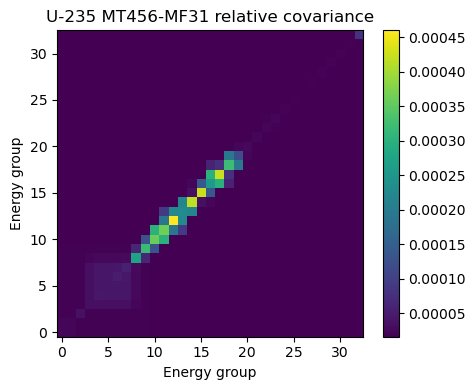

In [11]:
if HAS_SANDY:
    MT, MF = 456, 31
    cov_np = cov_u235.get(MT, MF=MF, to_numpy=True)
    assert isinstance(cov_np, np.ndarray)
    assert cov_np.shape == (33, 33)

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cov_np, origin="lower")
    ax.set_title(f"U-235 MT{MT}-MF{MF} relative covariance")
    ax.set_xlabel("Energy group")
    ax.set_ylabel("Energy group")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()

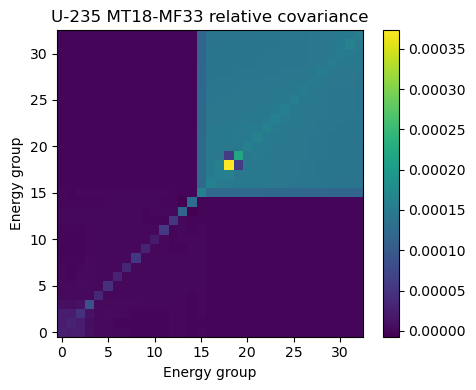

In [12]:
if HAS_SANDY:
    MT, MF = 18, 33
    cov_np = cov_u235.get(MT, MF=MF, to_numpy=True)
    assert isinstance(cov_np, np.ndarray)
    assert cov_np.shape == (33, 33)

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cov_np, origin="lower")
    ax.set_title(f"U-235 MT{MT}-MF{MF} relative covariance")
    ax.set_xlabel("Energy group")
    ax.set_ylabel("Energy group")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()

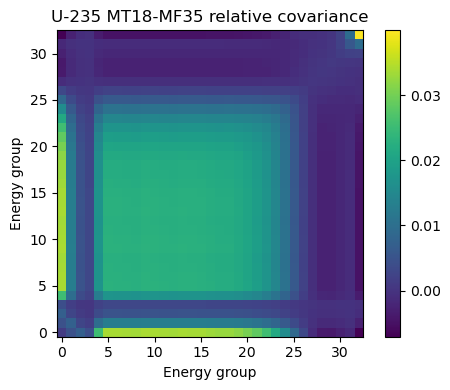

In [13]:
if HAS_SANDY:
    MT, MF = 18, 35
    cov_np = cov_u235.get(MT, MF=MF, to_numpy=True)
    assert isinstance(cov_np, np.ndarray)
    assert cov_np.shape == (33, 33)

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cov_np, origin="lower")
    ax.set_title(f"U-235 MT{MT}-MF{MF} relative covariance")
    ax.set_xlabel("Energy group")
    ax.set_ylabel("Energy group")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()